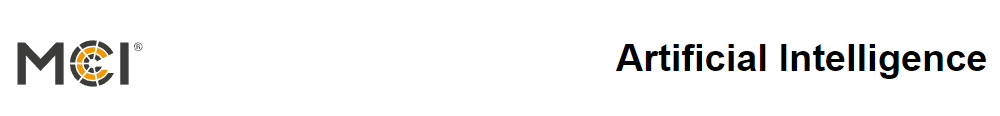

---

# 08 Clustering with support vector machines

Culster the Data of the MCI Darts experiment into several Clusters. Now though, we are using a support vector machine instead of kmeans

### 1.1. The Problem & Data Aquisition

Data is available as a numpy array through sakai

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# generate accesss to the drive (=data) there are all the labelled csv. files stored
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
championship_data=np.load('/content/drive/MyDrive/MCI Lehre/Artificial Intelligence/Data/Darts_Clustering/championship_data.npy')
print(championship_data.shape)
np.random.shuffle(championship_data)

(200, 2)


# 1.2. Processing and Analysis

As always we plot the data so we have an idea what it is all about

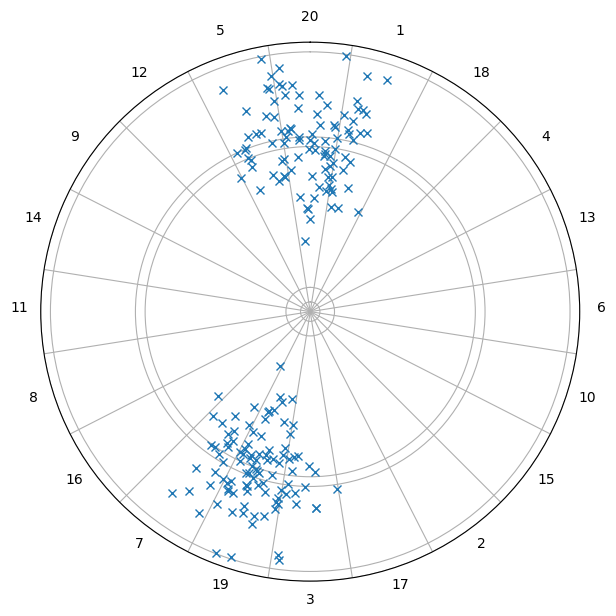

In [4]:
fig, axi = plt.subplots(subplot_kw={'projection': 'polar'})
fig.set_size_inches((7,7))

axi.plot(championship_data[:,1], championship_data[:,0],'x')

# the 5,20,1 etc. field grids
axi.set_thetagrids(list(range(9,369,18)),
         [" "," ", " ", " ", " ", " ", " ", " ", " ", " "
         , " ", " ", " ", " ", " ", " ", " ", " ", " ", " "]
        , verticalalignment='center'
        , horizontalalignment = 'center')
# the proportions radius of inners and outer circle

numbers_score=['20', '5', '12', '9', '14', '11', '8', '16', '7', '19', '3', '17', '2', '15', '10', '6', '13', '4', '18', '1']

for index in range(len(numbers_score)):
    plt.text(index/len(numbers_score)*2*np.pi, 7.5, numbers_score[index], ha='center', rotation=0, wrap=True)

rad = np.linspace(0, 6+11/16+1/4, 21)
azm = np.linspace(0, 2 * np.pi, 21)
axi.set_rgrids([0.1, 1.8])

# radius, r fields outer and inner bullseye
axi.set_rticks([1/4, 5/8, 17/4, 18/4, 6+11/16, 6+11/16+1/4])
axi.set_theta_zero_location("N",offset=0.0)
axi.set_yticklabels([])
radius, theta = np.meshgrid(rad, azm)

As SVM are supervised learning classification algorithms we need to to have an output vector so we can fit the data. Based on the observation of the plot we make it easy and say the bottom half of the the dart board was meant for the triple 19 and the top half of the board was ment for triple 20.

In [5]:
X=championship_data
y=np.int0(championship_data[:,1]<np.pi/2)

<ipython-input-5-2f9bb3444318>:2: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  y=np.int0(championship_data[:,1]<np.pi/2)


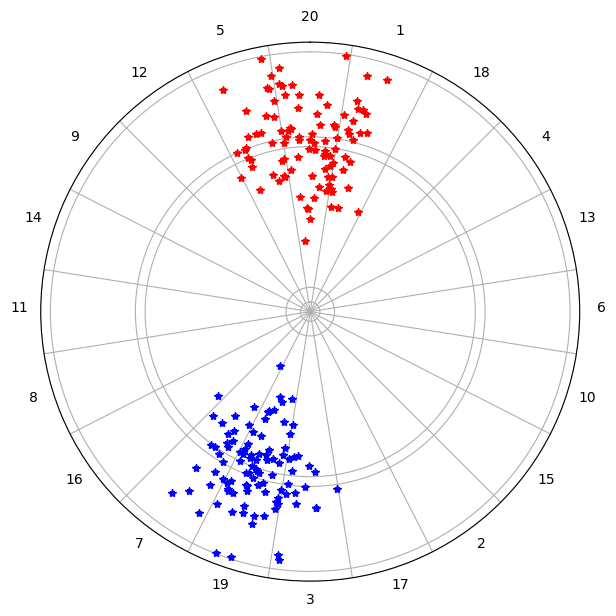

In [6]:
fig, axi = plt.subplots(subplot_kw={'projection': 'polar'})
fig.set_size_inches((7,7))

axi.plot(X[y==1,1], X[y==1,0],'r*')
axi.plot(X[y==0,1], X[y==0,0],'b*')

# the 5,20,1 etc. field grids
axi.set_thetagrids(list(range(9,369,18)),
         [" "," ", " ", " ", " ", " ", " ", " ", " ", " "
         , " ", " ", " ", " ", " ", " ", " ", " ", " ", " "]
        , verticalalignment='center'
        , horizontalalignment = 'center')
# the proportions radius of inners and outer circle

numbers_score=['20', '5', '12', '9', '14', '11', '8', '16', '7', '19', '3', '17', '2', '15', '10', '6', '13', '4', '18', '1']

for index in range(len(numbers_score)):
    plt.text(index/len(numbers_score)*2*np.pi, 7.5, numbers_score[index], ha='center', rotation=0, wrap=True)

rad = np.linspace(0, 6+11/16+1/4, 21)
azm = np.linspace(0, 2 * np.pi, 21)
axi.set_rgrids([0.1, 1.8])

# radius, r fields outer and inner bullseye
axi.set_rticks([1/4, 5/8, 17/4, 18/4, 6+11/16, 6+11/16+1/4])
axi.set_theta_zero_location("N",offset=0.0)
axi.set_yticklabels([])
radius, theta = np.meshgrid(rad, azm)

# 1.3 Develop the Algorithm for Clustering

Fit the data


In [7]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

As SVM work in a way that they maximize the margin between the classes, we use a function to visualize that (source: jakevdp, Jake VanderPlas)

In [8]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',
                   facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

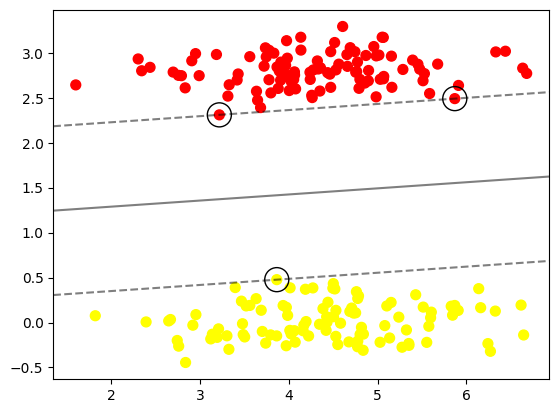

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

#### TASK: Play around with the modalities of the fit (kernal & C)